# Exercise: Log, Gamma, and Piecewise Linear Transformations

### Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [13]:
img = cv2.imread("img2.jpg", cv2.IMREAD_GRAYSCALE)
img_float = img.astype(np.float32)
img_float = np.clip(img_float, 0, 255)

## 1. Log Transformation
Apply log transformation and display original vs log transformed image side by side.

In [14]:
c = 255.0 / np.log(1 + 255)
log_transformed = c * np.log1p(img_float)
log_transformed = np.clip(log_transformed, 0, 255)
log_transformed = log_transformed.astype(np.uint8)

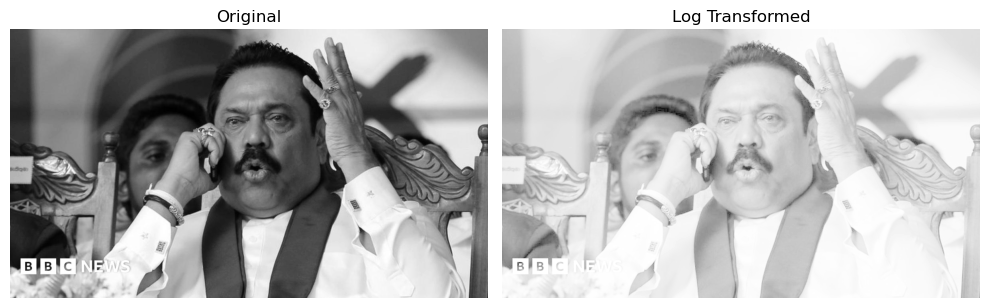

In [15]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img.astype(np.uint8), cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(log_transformed, cmap='gray')
plt.title("Log Transformed")
plt.axis('off')

plt.tight_layout()
plt.show()

## 2. Gamma Transformation
Apply two gamma transforms: one with gamma between 0.1 and 0.5 (brightens the image), and one with gamma between 2.0 and 4.0 (darkens the image). Display original and both results side by side.

In [16]:
normalized = img / 255.0

gamma1 = 0.3   # chosen between 0.1 and 0.5
gamma2 = 3.0   # chosen between 2.0 and 4.0

In [17]:
gamma_low = np.power(normalized, gamma1) * 255
gamma_low = np.clip(gamma_low, 0, 255)
gamma_low = gamma_low.astype(np.uint8)

In [18]:
gamma_high = np.power(normalized, gamma2) * 255
gamma_high = np.clip(gamma_high, 0, 255)
gamma_high = gamma_high.astype(np.uint8)

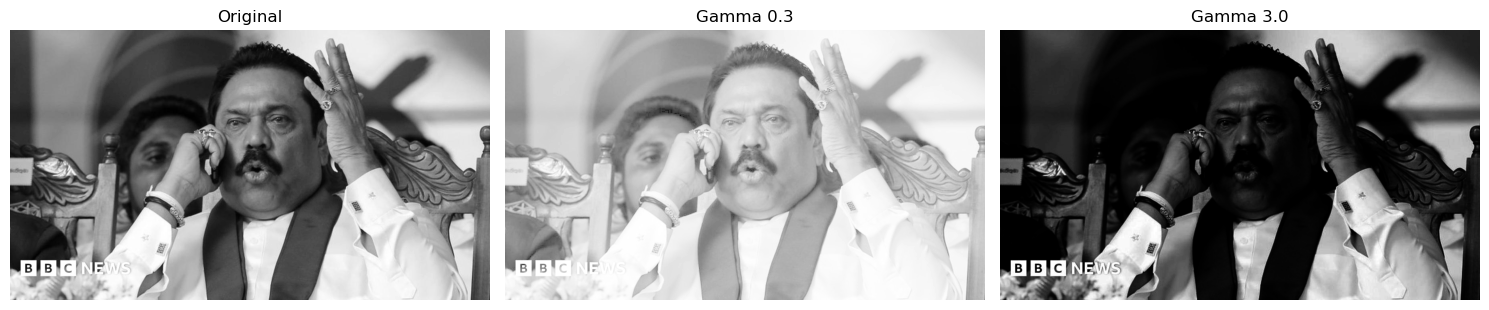

In [19]:
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(img.astype(np.uint8), cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(gamma_low, cmap='gray')
plt.title(f"Gamma {gamma1}")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(gamma_high, cmap='gray')
plt.title(f"Gamma {gamma2}")
plt.axis('off')

plt.tight_layout()
plt.show()

## 3. Piecewise Linear Transformation
Apply two piecewise linear (contrast stretching) transformations using different sets of control points, then display original and both results side by side.

In [20]:
'''
r = input intensity

r1 -> input intensity where first region ends
r2 -> input intensity where second region ends

s1 -> output value corresponding to r1
s2 -> output value corresponding to r2

0 -> r1   First linear transformation
r1 -> r2  Main stretching region
r2 -> 255 Third linear transformation
'''

def piecewise_linear(img, r1, s1, r2, s2):
    result = np.zeros_like(img, dtype=np.float32)

    region1 = img < r1
    result[region1] = (s1 / r1) * img[region1]

    region2 = (img >= r1) & (img <= r2)
    result[region2] = ((s2 - s1) / (r2 - r1)) * (img[region2] - r1) + s1

    region3 = img > r2
    result[region3] = ((255 - s2) / (255 - r2)) * (img[region3] - r2) + s2

    result = np.clip(result, 0, 255)
    return result.astype(np.uint8)

In [21]:
# First set of control points: strong contrast stretch
r1_a, s1_a = 70, 20
r2_a, s2_a = 180, 230

piecewise_result_1 = piecewise_linear(img, r1_a, s1_a, r2_a, s2_a)

In [22]:
# Second set of control points: different stretch (e.g. darken shadows, compress highlights)
r1_b, s1_b = 50, 10
r2_b, s2_b = 150, 200

piecewise_result_2 = piecewise_linear(img, r1_b, s1_b, r2_b, s2_b)

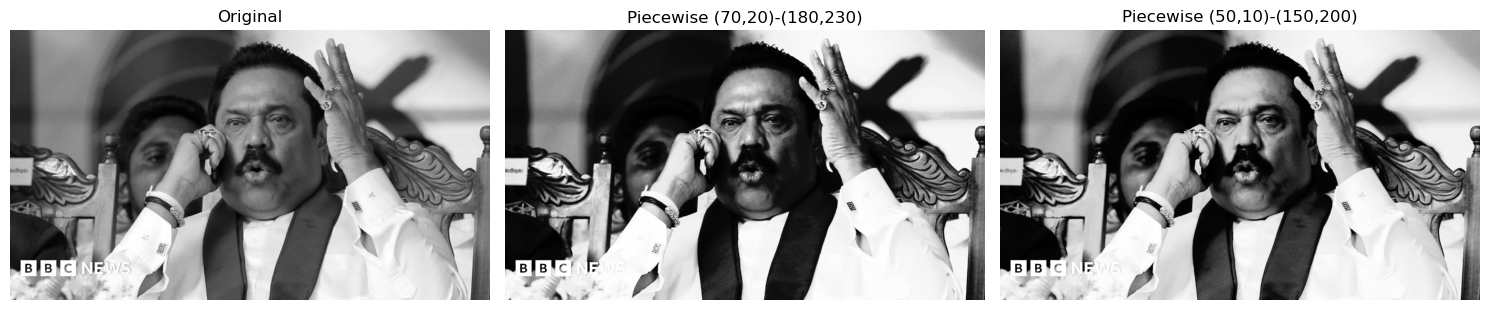

In [23]:
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(img.astype(np.uint8), cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(piecewise_result_1, cmap='gray')
plt.title(f"Piecewise ({r1_a},{s1_a})-({r2_a},{s2_a})")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(piecewise_result_2, cmap='gray')
plt.title(f"Piecewise ({r1_b},{s1_b})-({r2_b},{s2_b})")
plt.axis('off')

plt.tight_layout()
plt.show()